<a href="https://colab.research.google.com/github/dhavanavijaywork/ML-2_Dhavana/blob/main/ML2_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
columns = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species'
]
df = pd.read_csv(
    '/content/iris.csv',
    names=columns
)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['species'].value_counts())

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Class Distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [5]:
X = df[['sepal_length',
        'sepal_width',
        'petal_length',
        'petal_width']]
y = df['species']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object


In [6]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Encoded target:")
print(y[:10])

print("\nClass mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Encoded target:
[0 0 0 0 0 0 0 0 0 0]

Class mapping:
0 = Iris-setosa
1 = Iris-versicolor
2 = Iris-virginica


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
base_tree = DecisionTreeClassifier(
    random_state=42
)
bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print("Bagging predictions:")
print(y_pred_bagging)

Bagging predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(
    y_test,
    y_pred_bagging,
    average='weighted'
)
bagging_recall = recall_score(
    y_test,
    y_pred_bagging,
    average='weighted'
)
bagging_f1 = f1_score(
    y_test,
    y_pred_bagging,
    average='weighted'
)
print("Bagging Results")
print("--------------------")
print("Accuracy :", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall   :", bagging_recall)
print("F1 Score :", bagging_f1)

Bagging Results
--------------------
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613


In [10]:
print("Bagging Classification Report")
print(
    classification_report(
        y_test,
        y_pred_bagging,
        target_names=label_encoder.classes_
    )
)

Bagging Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



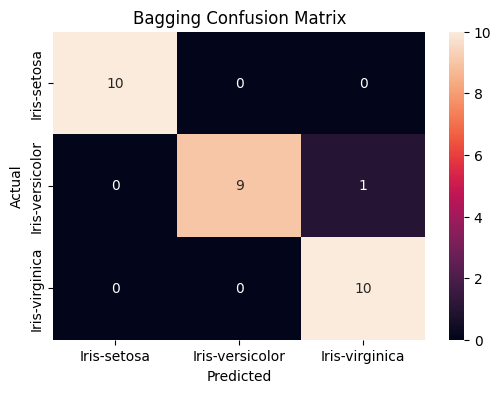

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
cm_bagging = confusion_matrix(
    y_test,
    y_pred_bagging
)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bagging,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Confusion Matrix")
plt.show()

In [12]:
from sklearn.ensemble import AdaBoostClassifier
weak_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)
boosting_model = AdaBoostClassifier(
    estimator=weak_tree,
    n_estimators=50,
    random_state=42
)
boosting_model.fit(X_train, y_train)
y_pred_boosting = boosting_model.predict(X_test)
print("Boosting predictions:")
print(y_pred_boosting)

Boosting predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [13]:
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)
boosting_precision = precision_score(
    y_test,
    y_pred_boosting,
    average='weighted'
)
boosting_recall = recall_score(
    y_test,
    y_pred_boosting,
    average='weighted'
)
boosting_f1 = f1_score(
    y_test,
    y_pred_boosting,
    average='weighted'
)
print("Boosting Results")
print("--------------------")
print("Accuracy :", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall   :", boosting_recall)
print("F1 Score :", boosting_f1)

Boosting Results
--------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1 Score : 0.9333333333333333


In [14]:
print("Boosting Classification Report")
print(
    classification_report(
        y_test,
        y_pred_boosting,
        target_names=label_encoder.classes_
    )
)

Boosting Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



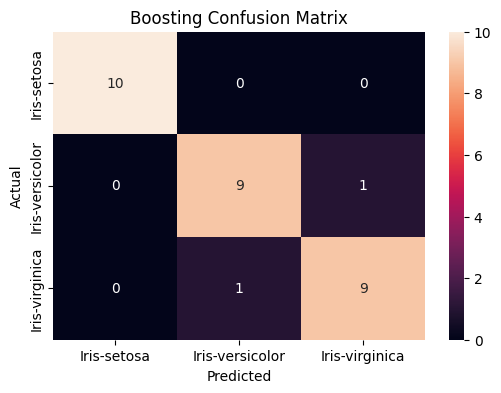

In [15]:
cm_boosting = confusion_matrix(
    y_test,
    y_pred_boosting
)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_boosting,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Boosting Confusion Matrix")
plt.show()

In [16]:
comparison = pd.DataFrame({
    'Model': ['Bagging', 'Boosting'],

    'Accuracy': [
        bagging_accuracy,
        boosting_accuracy
    ],

    'Precision': [
        bagging_precision,
        boosting_precision
    ],

    'Recall': [
        bagging_recall,
        boosting_recall
    ],

    'F1 Score': [
        bagging_f1,
        boosting_f1
    ]
})
print(comparison)

      Model  Accuracy  Precision    Recall  F1 Score
0   Bagging  0.966667   0.969697  0.966667  0.966583
1  Boosting  0.933333   0.933333  0.933333  0.933333


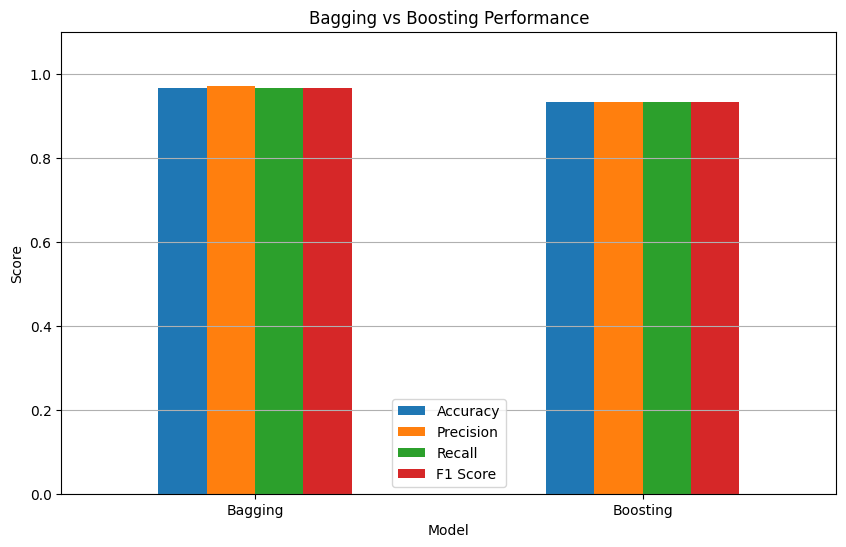

In [17]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [18]:
print("FINAL PERFORMANCE COMPARISON")

print(f"\nBagging:")
print(f"Accuracy  : {bagging_accuracy:.4f}")
print(f"Precision : {bagging_precision:.4f}")
print(f"Recall    : {bagging_recall:.4f}")
print(f"F1 Score  : {bagging_f1:.4f}")

print(f"\nBoosting:")
print(f"Accuracy  : {boosting_accuracy:.4f}")
print(f"Precision : {boosting_precision:.4f}")
print(f"Recall    : {boosting_recall:.4f}")
print(f"F1 Score  : {boosting_f1:.4f}")

FINAL PERFORMANCE COMPARISON

Bagging:
Accuracy  : 0.9667
Precision : 0.9697
Recall    : 0.9667
F1 Score  : 0.9666

Boosting:
Accuracy  : 0.9333
Precision : 0.9333
Recall    : 0.9333
F1 Score  : 0.9333
